In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [2]:
df = pd.read_csv("Fraud_Detection.csv")

In [3]:
df

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,Column1,isFraud - Copy,DayOfWeek,DayOfWeek(new)
0,7,PAYMENT,Espana,1526.50,C1908839976,0.0,0.0,M1304522697,0.00,0.00,7,0,Savings,03-Jan-18,Afternoon,Safe,7168,0.0,3.0,Wednesday
1,7,PAYMENT,Honduras,1620.17,C70432899,0.0,0.0,M252297858,0.00,0.00,2,0,Savings,05-Jan-18,Night,Safe,7211,0.0,5.0,Friday
2,7,PAYMENT,Indonesia,5689.82,C332151172,0.0,0.0,M1430674428,0.00,0.00,3,0,Savings,07-Jan-18,Morning,Safe,7268,0.0,7.0,Sunday
3,7,PAYMENT,Estados Unidos,2211.07,C1148172078,0.0,0.0,M650835126,0.00,0.00,13,0,Savings,06-Jan-18,Afternoon,Safe,7325,0.0,6.0,Saturday
4,7,PAYMENT,Estados Unidos,824.63,C1142006014,0.0,0.0,M745868137,0.00,0.00,7,0,Savings,06-Jan-18,Morning,Safe,7326,0.0,6.0,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,7,CASH_OUT,Estados Unidos,488632.10,C984363447,0.0,0.0,C465257140,590053.46,1078685.56,5,0,Savings,11-Jan-18,Night,Safe,8534,0.0,4.0,Thursday
10123,7,CASH_OUT,Estados Unidos,232784.28,C144560386,0.0,0.0,C909295153,8182056.73,9092634.94,16,0,Savings,19-Jan-18,Morning,Safe,8664,0.0,5.0,Friday
10124,7,CASH_OUT,Estados Unidos,223310.57,C1677203878,0.0,0.0,C1626759869,517791.72,592376.60,9,0,Savings,08-Jan-18,Morning,Safe,9441,0.0,1.0,Monday
10125,7,CASH_OUT,Estados Unidos,302788.52,C2082418981,0.0,0.0,C1671179293,367144.26,669932.79,9,0,Savings,13-Jan-18,Afternoon,Safe,9544,0.0,6.0,Saturday


In [4]:
df.head()

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,Column1,isFraud - Copy,DayOfWeek,DayOfWeek(new)
0,7,PAYMENT,Espana,1526.50,C1908839976,0.0,0.0,M1304522697,0.0,0.0,7,0,Savings,03-Jan-18,Afternoon,Safe,7168,0.0,3.0,Wednesday
1,7,PAYMENT,Honduras,1620.17,C70432899,0.0,0.0,M252297858,0.0,0.0,2,0,Savings,05-Jan-18,Night,Safe,7211,0.0,5.0,Friday
2,7,PAYMENT,Indonesia,5689.82,C332151172,0.0,0.0,M1430674428,0.0,0.0,3,0,Savings,07-Jan-18,Morning,Safe,7268,0.0,7.0,Sunday
3,7,PAYMENT,Estados Unidos,2211.07,C1148172078,0.0,0.0,M650835126,0.0,0.0,13,0,Savings,06-Jan-18,Afternoon,Safe,7325,0.0,6.0,Saturday
4,7,PAYMENT,Estados Unidos,824.63,C1142006014,0.0,0.0,M745868137,0.0,0.0,7,0,Savings,06-Jan-18,Morning,Safe,7326,0.0,6.0,Saturday


In [5]:
df.tail()

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,Column1,isFraud - Copy,DayOfWeek,DayOfWeek(new)
10122,7,CASH_OUT,Estados Unidos,488632.10,C984363447,0.0,0.0,C465257140,590053.46,1078685.56,5,0,Savings,11-Jan-18,Night,Safe,8534,0.0,4.0,Thursday
10123,7,CASH_OUT,Estados Unidos,232784.28,C144560386,0.0,0.0,C909295153,8182056.73,9092634.94,16,0,Savings,19-Jan-18,Morning,Safe,8664,0.0,5.0,Friday
10124,7,CASH_OUT,Estados Unidos,223310.57,C1677203878,0.0,0.0,C1626759869,517791.72,592376.60,9,0,Savings,08-Jan-18,Morning,Safe,9441,0.0,1.0,Monday
10125,7,CASH_OUT,Estados Unidos,302788.52,C2082418981,0.0,0.0,C1671179293,367144.26,669932.79,9,0,Savings,13-Jan-18,Afternoon,Safe,9544,0.0,6.0,Saturday
10126,7,CASH_OUT,Estados Unidos,36600.63,C1157016655,0.0,0.0,C169904524,215766.61,252367.25,9,0,Savings,05-Jan-18,Night,Safe,9857,0.0,5.0,Friday


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   step                 10127 non-null  int64  
 1   type                 10123 non-null  object 
 2   branch               10127 non-null  object 
 3   amount               10125 non-null  float64
 4   nameOrig             10121 non-null  object 
 5   oldbalanceOrg        10125 non-null  float64
 6   newbalanceOrig       10127 non-null  float64
 7   nameDest             10121 non-null  object 
 8   oldbalanceDest       10126 non-null  float64
 9   newbalanceDest       10125 non-null  float64
 10  unusuallogin         10127 non-null  int64  
 11  isFlaggedFraud       10127 non-null  int64  
 12  Acct type            10117 non-null  object 
 13  Date of transaction  10120 non-null  object 
 14  Time of day          10125 non-null  object 
 15  isFraud              10127 non-null 

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Column1,isFraud - Copy,DayOfWeek
count,10127.000000,1.012500e+04,1.012500e+04,1.012700e+04,1.012600e+04,1.012500e+04,10127.000000,10127.0,10127.000000,10125.000000,10120.000000
mean,4.214279,1.048869e+05,8.836965e+05,9.044703e+05,9.335393e+05,1.109315e+06,10.513183,0.0,5063.000000,0.006716,4.214921
std,2.484139,2.706369e+05,2.124554e+06,2.169946e+06,2.677976e+06,3.048644e+06,5.809233,0.0,2923.557422,0.081680,1.739354
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000,1.000000
25%,1.000000,4.397380e+03,1.290000e+02,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,0.0,2531.500000,0.000000,3.000000
50%,5.000000,1.279831e+04,2.136300e+04,1.021224e+04,0.000000e+00,0.000000e+00,10.000000,0.0,5063.000000,0.000000,5.000000
75%,7.000000,1.143818e+05,1.724320e+05,1.707240e+05,2.819345e+05,2.523925e+05,16.000000,0.0,7594.500000,0.000000,6.000000
max,7.000000,1.000000e+07,1.290000e+07,1.300000e+07,1.950000e+07,2.260000e+07,20.000000,0.0,10126.000000,1.000000,7.000000


In [8]:
df.columns

Index(['step', 'type', 'branch', 'amount', 'nameOrig', 'oldbalanceOrg',
       'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest',
       'unusuallogin', 'isFlaggedFraud', 'Acct type', 'Date of transaction',
       'Time of day', 'isFraud', 'Column1', 'isFraud - Copy', 'DayOfWeek',
       'DayOfWeek(new)'],
      dtype='object')

In [9]:
df.shape

(10127, 20)

In [10]:
df.isnull().sum()


step                    0
type                    4
branch                  0
amount                  2
nameOrig                6
oldbalanceOrg           2
newbalanceOrig          0
nameDest                6
oldbalanceDest          1
newbalanceDest          2
unusuallogin            0
isFlaggedFraud          0
Acct type              10
Date of transaction     7
Time of day             2
isFraud                 0
Column1                 0
isFraud - Copy          2
DayOfWeek               7
DayOfWeek(new)          7
dtype: int64

In [11]:
# Fill numerical missing values with median

num_cols = [
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud - Copy",
    "DayOfWeek"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values handled successfully.")

Numerical missing values handled successfully.


In [12]:
cat_cols = [
    "type",
    "nameOrig",
    "nameDest",
    "Acct type",
    "Date of transaction",
    "Time of day",
    "DayOfWeek(new)"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical missing values handled successfully.")

Categorical missing values handled successfully.


In [13]:
df.isnull().sum()

step                   0
type                   0
branch                 0
amount                 0
nameOrig               0
oldbalanceOrg          0
newbalanceOrig         0
nameDest               0
oldbalanceDest         0
newbalanceDest         0
unusuallogin           0
isFlaggedFraud         0
Acct type              0
Date of transaction    0
Time of day            0
isFraud                0
Column1                0
isFraud - Copy         0
DayOfWeek              0
DayOfWeek(new)         0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.dtypes

step                     int64
type                    object
branch                  object
amount                 float64
nameOrig                object
oldbalanceOrg          float64
newbalanceOrig         float64
nameDest                object
oldbalanceDest         float64
newbalanceDest         float64
unusuallogin             int64
isFlaggedFraud           int64
Acct type               object
Date of transaction     object
Time of day             object
isFraud                 object
Column1                  int64
isFraud - Copy         float64
DayOfWeek              float64
DayOfWeek(new)          object
dtype: object

In [16]:
df["isFraud"].value_counts()

isFraud
Safe            10057
Fraud              68
Not reviewed        2
Name: count, dtype: int64

In [17]:
(df["isFraud"].value_counts(normalize=True)*100).round(2)

isFraud
Safe            99.31
Fraud            0.67
Not reviewed     0.02
Name: proportion, dtype: float64

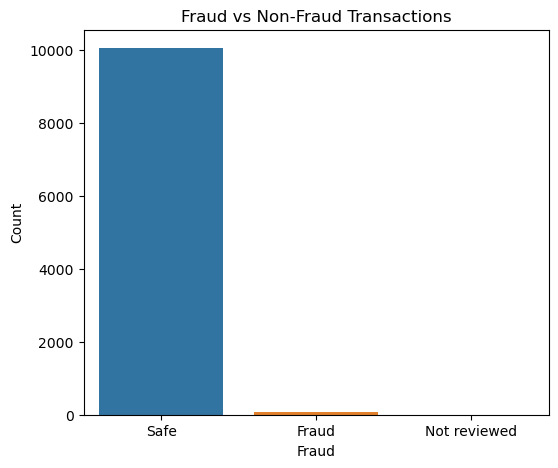

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

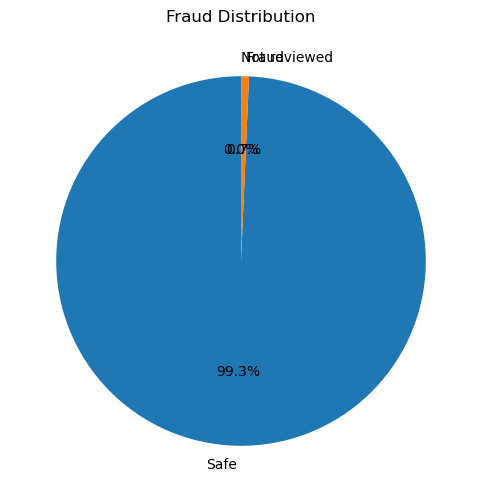

In [19]:
plt.figure(figsize=(6,6))

df["isFraud"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Fraud Distribution")

plt.show()

In [20]:
df["type"].value_counts()

type
PAYMENT     5545
CASH_IN     1953
CASH_OUT    1337
TRANSFER     946
DEBIT        346
Name: count, dtype: int64

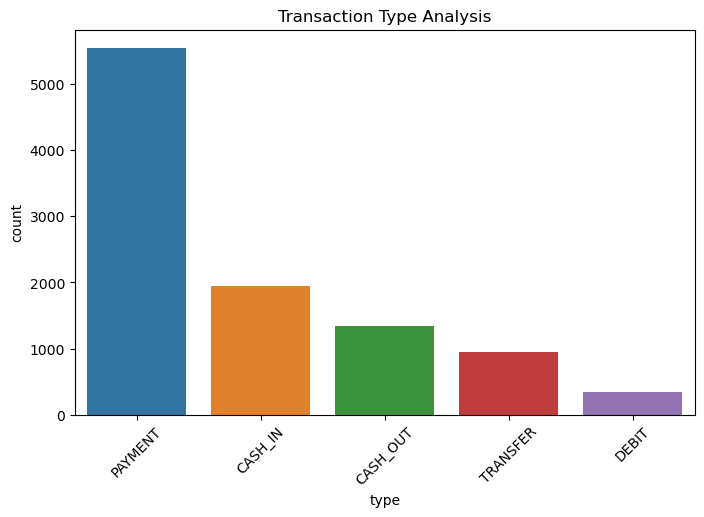

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="type",
    data=df,
    order=df["type"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Transaction Type Analysis")

plt.show()

In [22]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,Fraud,Not reviewed,Safe
type,,,
CASH_IN,0,0,1953
CASH_OUT,35,1,1301
DEBIT,0,0,346
PAYMENT,0,1,5544
TRANSFER,33,0,913


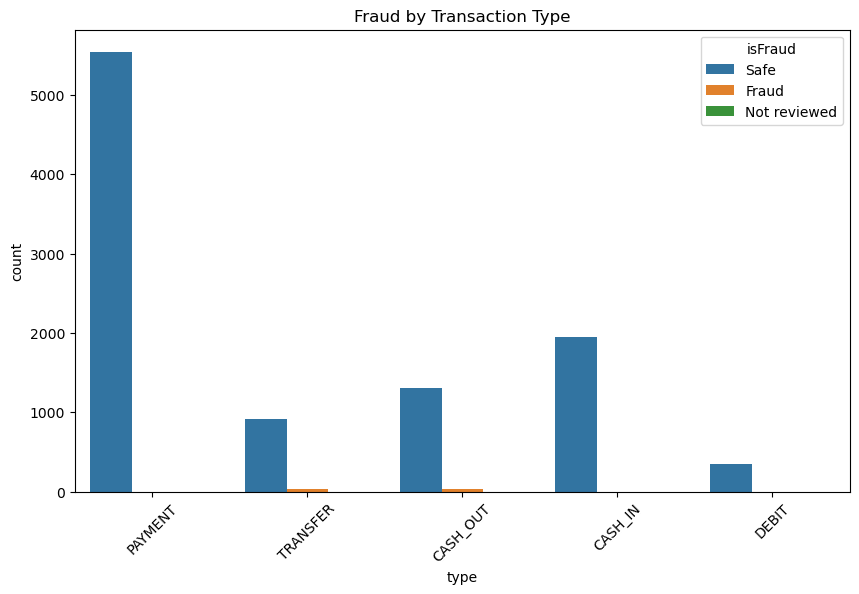

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="type",
    hue="isFraud",
    data=df
)

plt.xticks(rotation=45)

plt.title("Fraud by Transaction Type")

plt.show()

In [24]:
df["branch"].value_counts()

branch
Estados Unidos            1283
Francia                    735
Mexico                     670
Australia                  633
Alemania                   499
                          ... 
Barein                       1
Emiratos arabes Unidos       1
Sri Lanka                    1
Lesoto                       1
Bosnia y Herzegovina         1
Name: count, Length: 135, dtype: int64

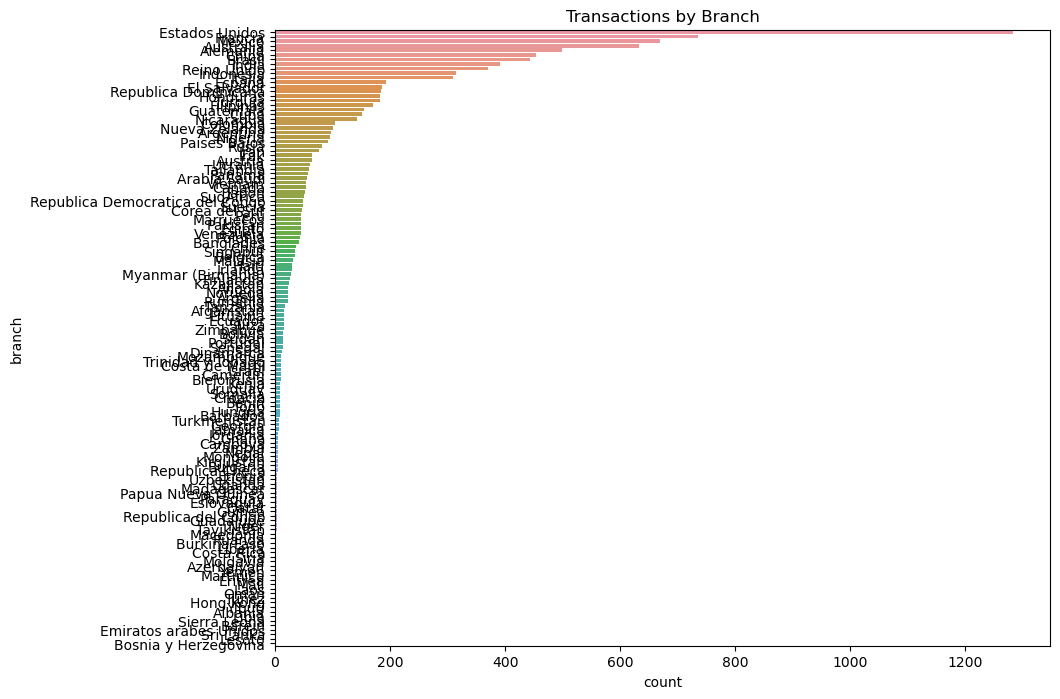

In [25]:
plt.figure(figsize=(10,8))

sns.countplot(
    y="branch",
    data=df,
    order=df["branch"].value_counts().index
)

plt.title("Transactions by Branch")

plt.show()

In [26]:
pd.crosstab(df["branch"], df["isFraud"])

isFraud,Fraud,Not reviewed,Safe
branch,,,
Afganistan,1,0,15
Albania,0,0,1
Alemania,0,0,499
Angola,0,0,23
Arabia Saudi,2,0,54
...,...,...,...
Vietnam,0,0,54
Yemen,0,0,2
Yibuti,0,0,1


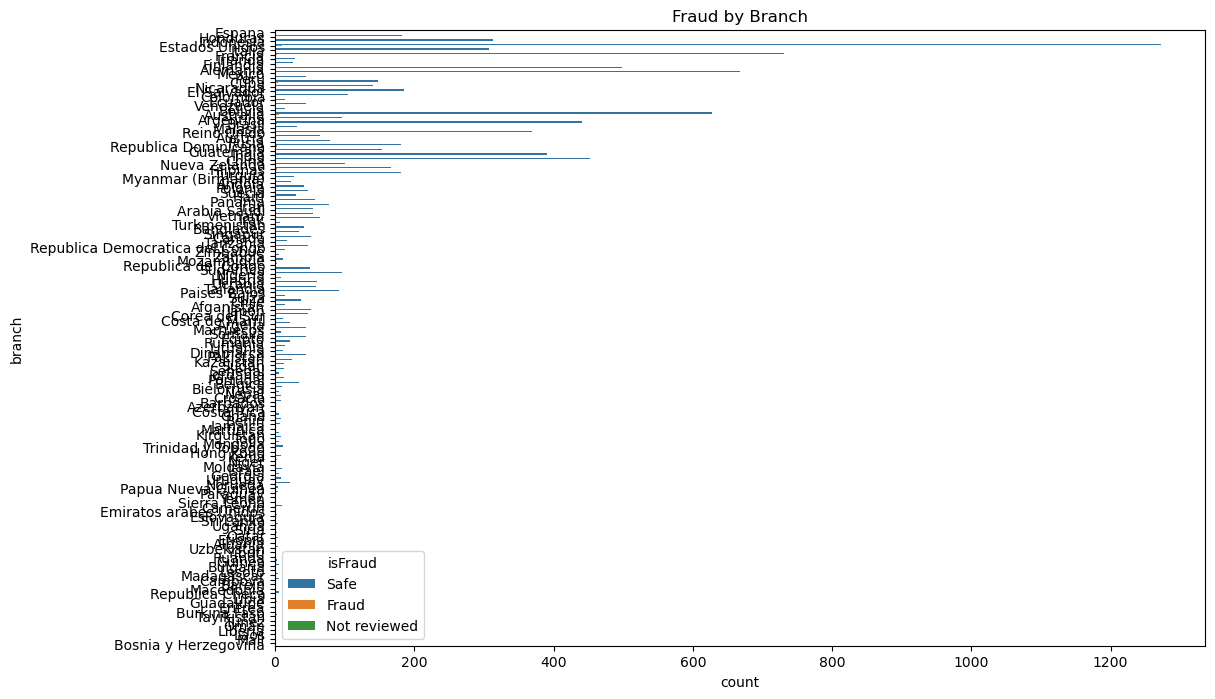

In [27]:
plt.figure(figsize=(12,8))

sns.countplot(
    y="branch",
    hue="isFraud",
    data=df
)

plt.title("Fraud by Branch")

plt.show()

In [28]:
df["amount"].describe()

count    1.012700e+04
mean     1.048687e+05
std      2.706133e+05
min      2.390000e+00
25%      4.397480e+03
50%      1.279831e+04
75%      1.143687e+05
max      1.000000e+07
Name: amount, dtype: float64

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


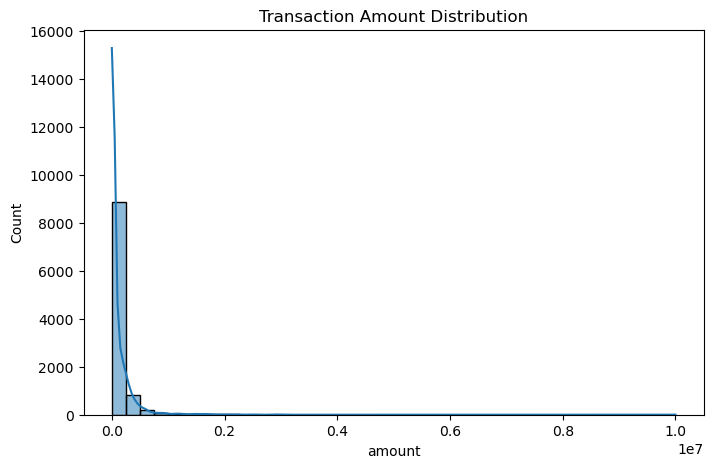

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=40, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

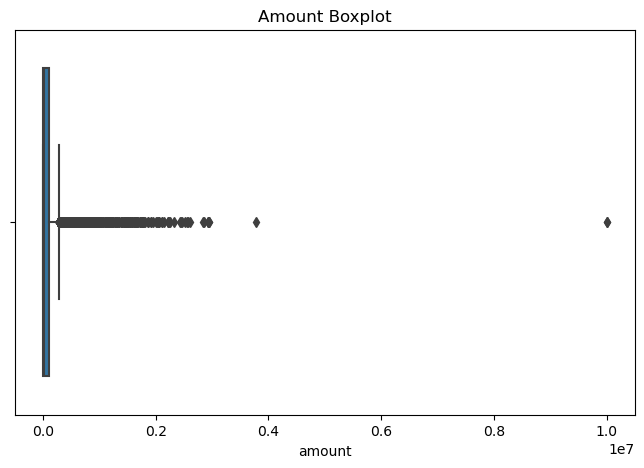

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Amount Boxplot")

plt.show()

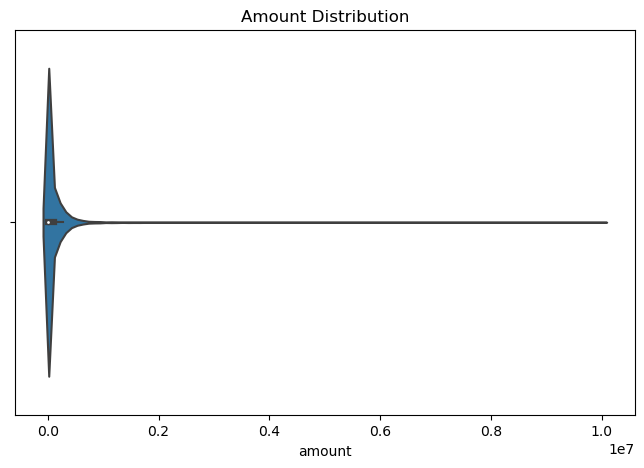

In [31]:
plt.figure(figsize=(8,5))

sns.violinplot(x=df["amount"])

plt.title("Amount Distribution")

plt.show()

In [32]:
df[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04
mean,8.835262e+05,9.044703e+05,9.334471e+05,1.109096e+06
std,2.124379e+06,2.169946e+06,2.677860e+06,3.048383e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.295000e+02,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.136300e+04,1.021224e+04,0.000000e+00,0.000000e+00
75%,1.724277e+05,1.707240e+05,2.819087e+05,2.523799e+05
max,1.290000e+07,1.300000e+07,1.950000e+07,2.260000e+07


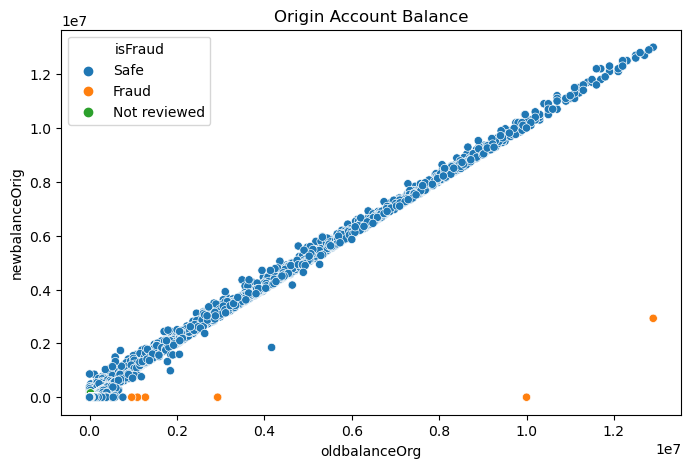

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="oldbalanceOrg",
    y="newbalanceOrig",
    hue="isFraud",
    data=df
)

plt.title("Origin Account Balance")

plt.show()

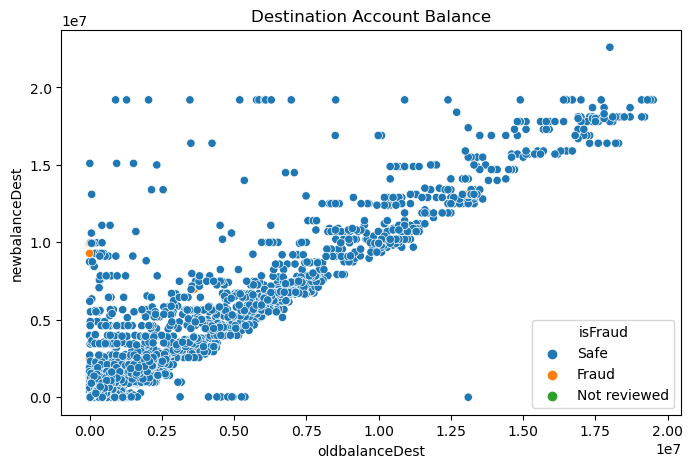

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="oldbalanceDest",
    y="newbalanceDest",
    hue="isFraud",
    data=df
)

plt.title("Destination Account Balance")

plt.show()

In [35]:
df["unusuallogin"].value_counts()

unusuallogin
18    550
20    539
2     526
19    522
8     522
11    521
12    515
9     514
6     514
1     511
10    508
3     508
16    502
13    494
4     493
7     491
5     484
17    477
14    467
15    465
0       4
Name: count, dtype: int64

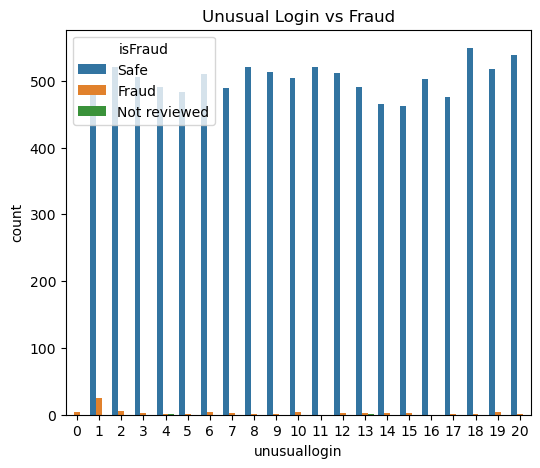

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="unusuallogin",
    hue="isFraud",
    data=df
)

plt.title("Unusual Login vs Fraud")

plt.show()

In [37]:
pd.crosstab(df["unusuallogin"], df["isFraud"])

isFraud,Fraud,Not reviewed,Safe
unusuallogin,,,
0,4,0,0
1,25,0,486
2,6,0,520
3,2,0,506
4,1,1,491
5,1,0,483
6,4,0,510
7,2,0,489
8,1,0,521


In [38]:
df["Acct type"].value_counts()

Acct type
Savings    6997
Current    3130
Name: count, dtype: int64

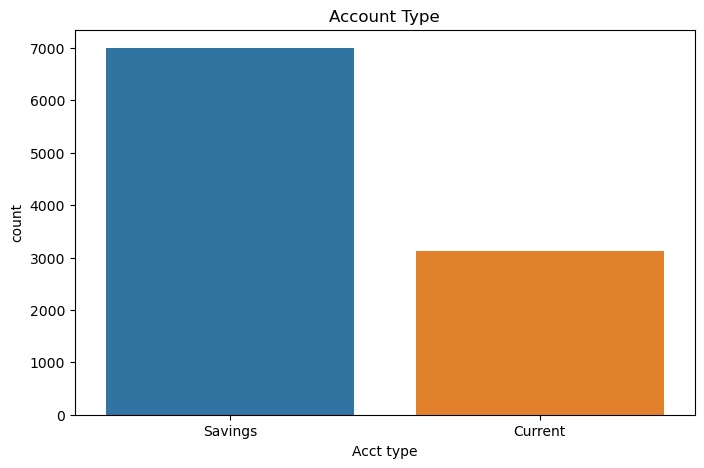

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Acct type",
    data=df
)

plt.title("Account Type")

plt.show()

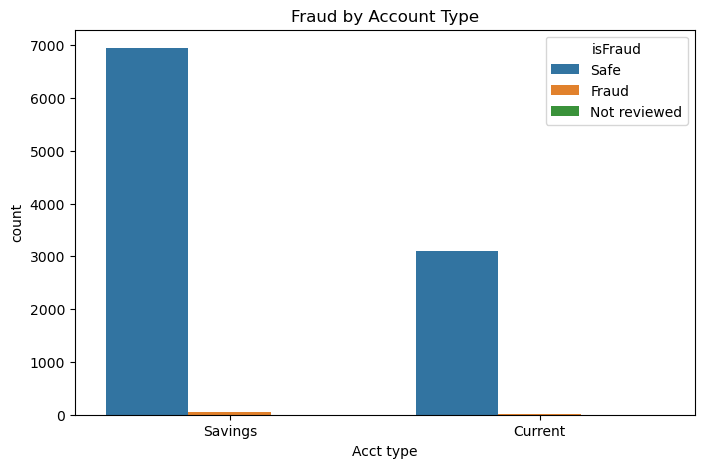

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Acct type",
    hue="isFraud",
    data=df
)

plt.title("Fraud by Account Type")

plt.show()

In [41]:
correlation = df.select_dtypes(include=["number"]).corr()

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


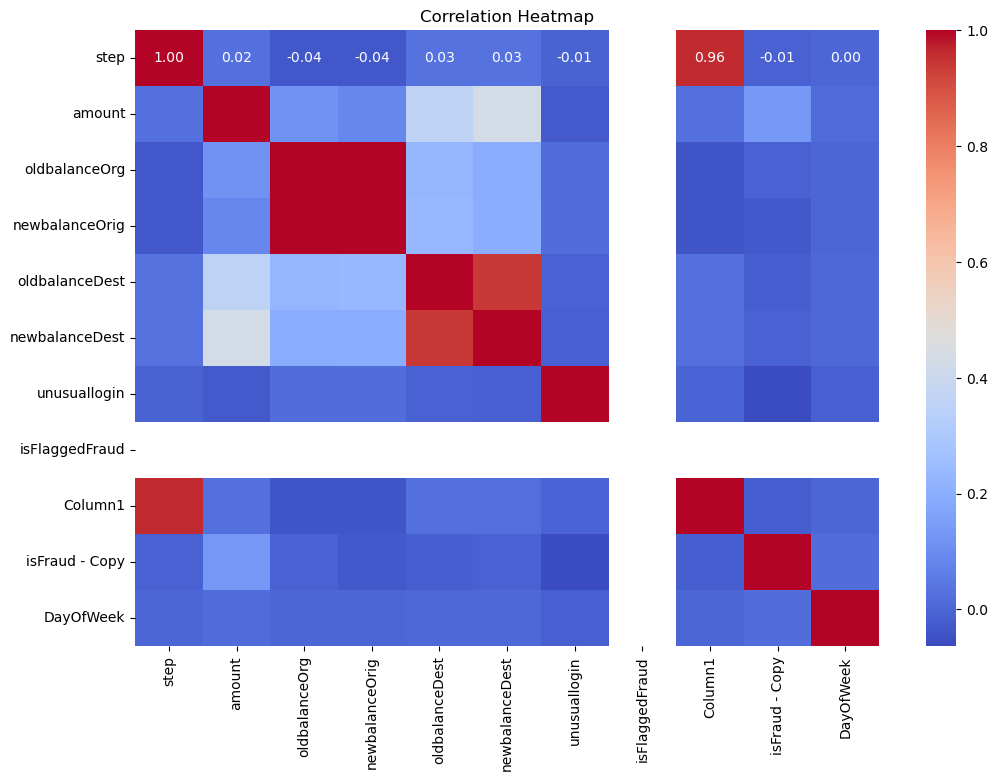

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

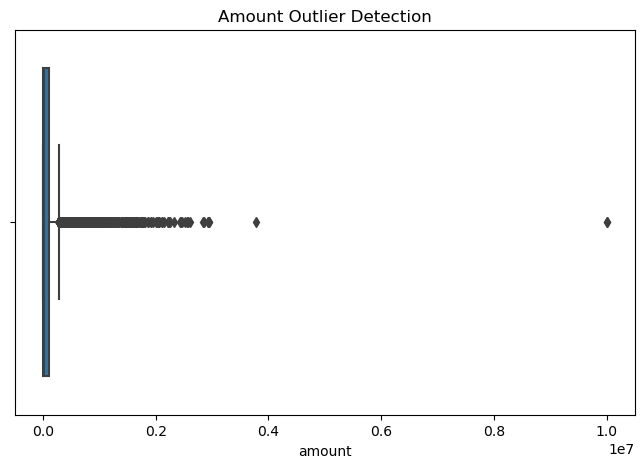

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Amount Outlier Detection")

plt.show()

In [44]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

outliers = df[(df["amount"] < Lower) | (df["amount"] > Upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1059


In [45]:
outliers.head()

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,Column1,isFraud - Copy,DayOfWeek,DayOfWeek(new)
1113,1,TRANSFER,Italia,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,6,0,Savings,06-Jan-18,Afternoon,Fraud,969,1.0,6.0,Saturday
1117,2,TRANSFER,Mexico,1096187.24,C1093223281,1096187.24,0.0,C2063275841,0.0,0.00,2,0,Current,10-Jan-18,Night,Fraud,3059,1.0,3.0,Wednesday
1118,2,TRANSFER,Republica Dominicana,963532.14,C1440057381,963532.14,0.0,C268086000,0.0,0.00,1,0,Savings,19-Jan-18,Morning,Fraud,3162,1.0,5.0,Friday
1123,4,TRANSFER,Nicaragua,2930418.44,C2047521920,2930418.44,0.0,C449261773,0.0,0.00,1,0,Savings,06-Jan-18,Night,Fraud,4442,1.0,6.0,Saturday
2023,1,TRANSFER,Vietnam,621561.65,C82275756,123122.00,0.0,C1782113663,0.0,3997768.55,1,0,Savings,06-Jan-18,Afternoon,Safe,830,0.0,6.0,Saturday


In [46]:
# Convert Time of day into Transaction Hour

hour_map = {
    "Morning": 9,
    "Afternoon": 14,
    "Evening": 19,
    "Night": 22
}

df["TransactionHour"] = df["Time of day"].map(hour_map)

df[["Time of day","TransactionHour"]].head()

,Time of day,TransactionHour
0,Afternoon,14
1,Night,22
2,Morning,9
3,Afternoon,14
4,Morning,9


In [47]:
df["Date of transaction"] = pd.to_datetime(
    df["Date of transaction"],
    format="%d-%b-%y"
)

df["TransactionMonth"] = df["Date of transaction"].dt.month

df[["Date of transaction","TransactionMonth"]].head()

,Date of transaction,TransactionMonth
0,2018-01-03,1
1,2018-01-05,1
2,2018-01-07,1
3,2018-01-06,1
4,2018-01-06,1


In [48]:
df["TransactionDay"] = df["Date of transaction"].dt.day

df[["Date of transaction","TransactionDay"]].head()

,Date of transaction,TransactionDay
0,2018-01-03,3
1,2018-01-05,5
2,2018-01-07,7
3,2018-01-06,6
4,2018-01-06,6


In [49]:
df["WeekendTransaction"] = df["Date of transaction"].dt.dayofweek.isin([5,6]).astype(int)

df[["Date of transaction","WeekendTransaction"]].head()

,Date of transaction,WeekendTransaction
0,2018-01-03,0
1,2018-01-05,0
2,2018-01-07,1
3,2018-01-06,1
4,2018-01-06,1


In [50]:
threshold = df["amount"].quantile(0.75)

df["HighAmountTransaction"] = (df["amount"] > threshold).astype(int)

df[["amount","HighAmountTransaction"]].head()

,amount,HighAmountTransaction
0,1526.50,0
1,1620.17,0
2,5689.82,0
3,2211.07,0
4,824.63,0


In [51]:
df["BalanceDifference"] = (
    df["oldbalanceOrg"] -
    df["newbalanceOrig"]
)

df[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "BalanceDifference"
]].head()

,oldbalanceOrg,newbalanceOrig,BalanceDifference
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [52]:
df["FraudRiskLevel"] = "Low"

df.loc[
    (df["HighAmountTransaction"] == 1) &
    (df["unusuallogin"] > 5),
    "FraudRiskLevel"
] = "High"

df.loc[
    (df["HighAmountTransaction"] == 1) &
    (df["unusuallogin"] <= 5),
    "FraudRiskLevel"
] = "Medium"

df["FraudRiskLevel"].value_counts()

FraudRiskLevel
Low       7595
High      1866
Medium     666
Name: count, dtype: int64

In [53]:
branch_risk = df.groupby("branch")["isFraud - Copy"].mean()

df["BranchRisk"] = df["branch"].map(branch_risk)

df[["branch","BranchRisk"]].head()

,branch,BranchRisk
0,Espana,0.000000
1,Honduras,0.000000
2,Indonesia,0.006349
3,Estados Unidos,0.007794
4,Estados Unidos,0.007794


In [54]:
df["LoginRisk"] = df["unusuallogin"].apply(
    lambda x: "High" if x >= 5 else "Low"
)

df[["unusuallogin","LoginRisk"]].head()

,unusuallogin,LoginRisk
0,7,High
1,2,Low
2,3,Low
3,13,High
4,7,High


In [55]:
df["TransactionCategory"] = pd.cut(
    df["amount"],
    bins=[0,1000,10000,50000,1000000],
    labels=["Small","Medium","Large","Very Large"]
)

df[["amount","TransactionCategory"]].head()

,amount,TransactionCategory
0,1526.50,Medium
1,1620.17,Medium
2,5689.82,Medium
3,2211.07,Medium
4,824.63,Small


In [56]:
new_features = [
    "TransactionHour",
    "TransactionMonth",
    "TransactionDay",
    "WeekendTransaction",
    "HighAmountTransaction",
    "BalanceDifference",
    "FraudRiskLevel",
    "BranchRisk",
    "LoginRisk",
    "TransactionCategory"
]

df[new_features].head()

,TransactionHour,TransactionMonth,TransactionDay,WeekendTransaction,HighAmountTransaction,BalanceDifference,FraudRiskLevel,BranchRisk,LoginRisk,TransactionCategory
0,14,1,3,0,0,0.0,Low,0.000000,High,Medium
1,22,1,5,0,0,0.0,Low,0.000000,Low,Medium
2,9,1,7,1,0,0.0,Low,0.006349,Low,Medium
3,14,1,6,1,0,0.0,Low,0.007794,High,Medium
4,9,1,6,1,0,0.0,Low,0.007794,High,Small


In [57]:
df.to_csv("Fraud_Detection_Feature_Engineered.csv", index=False)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Acct type"] = le.fit_transform(df["Acct type"])

df["Time of day"] = le.fit_transform(df["Time of day"])

df["DayOfWeek(new)"] = le.fit_transform(df["DayOfWeek(new)"])

df["isFraud"] = le.fit_transform(df["isFraud"])

In [59]:
df[["Acct type","Time of day","DayOfWeek(new)","isFraud"]].head()

,Acct type,Time of day,DayOfWeek(new),isFraud
0,1,0,6,2
1,1,2,0,2
2,1,1,3,2
3,1,0,2,2
4,1,1,2,2


In [60]:
df = pd.get_dummies(
    df,
    columns=["type", "branch"],
    drop_first=True
)

In [61]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,...,branch_Ucrania,branch_Uganda,branch_Uruguay,branch_Uzbekistan,branch_Venezuela,branch_Vietnam,branch_Yemen,branch_Yibuti,branch_Zambia,branch_Zimbabue
0,7,1526.50,C1908839976,0.0,0.0,M1304522697,0.0,0.0,7,0,...,False,False,False,False,False,False,False,False,False,False
1,7,1620.17,C70432899,0.0,0.0,M252297858,0.0,0.0,2,0,...,False,False,False,False,False,False,False,False,False,False
2,7,5689.82,C332151172,0.0,0.0,M1430674428,0.0,0.0,3,0,...,False,False,False,False,False,False,False,False,False,False
3,7,2211.07,C1148172078,0.0,0.0,M650835126,0.0,0.0,13,0,...,False,False,False,False,False,False,False,False,False,False
4,7,824.63,C1142006014,0.0,0.0,M745868137,0.0,0.0,7,0,...,False,False,False,False,False,False,False,False,False,False


In [62]:
y = df["isFraud - Copy"]

In [63]:
X = df.drop(columns=[
    "isFraud",
    "isFraud - Copy",
    "nameOrig",
    "nameDest",
    "Date of transaction"
])

In [64]:
print(X.shape)
print(y.shape)

(10127, 161)
(10127,)


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8101, 161)
(2026, 161)
(8101,)
(2026,)


In [75]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [81]:
numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "unusuallogin",
    "isFlaggedFraud",
    "Column1",
    "DayOfWeek"
]

In [83]:
X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [85]:
X_train.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Time of day,...,branch_Ucrania,branch_Uganda,branch_Uruguay,branch_Uzbekistan,branch_Venezuela,branch_Vietnam,branch_Yemen,branch_Yibuti,branch_Zambia,branch_Zimbabue
387,0.166667,-0.056362,-0.128571,-0.062254,0.000000,0.000000,-0.8,0.0,1,0,...,False,False,False,False,False,False,False,False,False,False
1097,0.333333,0.153646,-0.128571,-0.062254,0.000000,0.000000,0.3,0.0,0,2,...,False,False,False,False,False,False,False,False,False,False
6413,-0.166667,0.989031,41.811574,42.790357,23.960317,27.191284,1.0,0.0,0,2,...,False,False,False,False,False,False,False,False,False,False
2105,0.166667,0.889803,0.123270,-0.062254,0.000000,0.441227,0.3,0.0,0,2,...,False,False,False,False,False,False,False,False,False,False
6058,0.333333,0.282460,36.283341,36.771161,1.066399,0.680201,0.5,0.0,1,0,...,False,False,False,False,False,False,False,False,False,False


In [87]:
print(y_train.value_counts())

isFraud - Copy
0.0    8047
1.0      54
Name: count, dtype: int64


In [91]:
print(X_train.dtypes)

step               float64
amount             float64
oldbalanceOrg      float64
newbalanceOrig     float64
oldbalanceDest     float64
                    ...   
branch_Vietnam        bool
branch_Yemen          bool
branch_Yibuti         bool
branch_Zambia         bool
branch_Zimbabue       bool
Length: 161, dtype: object


In [93]:
print(X_train.select_dtypes(include=['object']).columns)

Index(['FraudRiskLevel', 'LoginRisk'], dtype='object')


In [95]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Dono datasets ke columns same karo
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [103]:
print(y_train_smote.value_counts())

isFraud - Copy
0.0    8047
1.0    8047
Name: count, dtype: int64


In [105]:
print("Original Training Shape :", X_train.shape)
print("Training Shape After SMOTE :", X_train_smote.shape)

print()

print("Original Target Distribution")
print(y_train.value_counts())

print()

print("Balanced Target Distribution")
print(y_train_smote.value_counts())

Original Training Shape : (8101, 164)
Training Shape After SMOTE : (16094, 164)

Original Target Distribution
isFraud - Copy
0.0    8047
1.0      54
Name: count, dtype: int64

Balanced Target Distribution
isFraud - Copy
0.0    8047
1.0    8047
Name: count, dtype: int64


In [107]:
train_data = X_train_smote.copy()
train_data["Target"] = y_train_smote

train_data.to_csv(
    "Fraud_Detection_Preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [113]:
lr = LogisticRegression(random_state=42, max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9837117472852912
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      2012
         1.0       0.28      0.86      0.42        14

    accuracy                           0.98      2026
   macro avg       0.64      0.92      0.71      2026
weighted avg       0.99      0.98      0.99      2026



In [115]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9925962487660415
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2012
         1.0       0.45      0.36      0.40        14

    accuracy                           0.99      2026
   macro avg       0.73      0.68      0.70      2026
weighted avg       0.99      0.99      0.99      2026



In [117]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9960513326752222
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2012
         1.0       1.00      0.43      0.60        14

    accuracy                           1.00      2026
   macro avg       1.00      0.71      0.80      2026
weighted avg       1.00      1.00      1.00      2026



In [119]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.8953603158933859
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.94      2012
         1.0       0.05      0.86      0.10        14

    accuracy                           0.90      2026
   macro avg       0.53      0.88      0.52      2026
weighted avg       0.99      0.90      0.94      2026



In [121]:
svc = SVC(random_state=42)

svc.fit(X_train_smote, y_train_smote)

y_pred_svc = svc.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

Accuracy : 0.9254689042448174
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96      2012
         1.0       0.06      0.64      0.11        14

    accuracy                           0.93      2026
   macro avg       0.53      0.79      0.53      2026
weighted avg       0.99      0.93      0.96      2026



In [123]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.9965449160908193
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2012
         1.0       0.89      0.57      0.70        14

    accuracy                           1.00      2026
   macro avg       0.94      0.79      0.85      2026
weighted avg       1.00      1.00      1.00      2026



In [125]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train_smote, y_train_smote)

y_pred_lgb = lgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8047, number of negative: 8047
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2998
[LightGBM] [Info] Number of data points in the train set: 16094, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy : 0.9960513326752222
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2012
         1.0       0.88      0.50      0.64        14

    accuracy                           1.00      2026
   macro avg       0.94      0.75      0.82      2026
weighted avg       1.00      1.00      1.00      2026



In [127]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso.fit(X_train)

pred = iso.predict(X_test)

pred = [1 if x == -1 else 0 for x in pred]

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Accuracy : 0.9738400789733465
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      2012
         1.0       0.00      0.00      0.00        14

    accuracy                           0.97      2026
   macro avg       0.50      0.49      0.49      2026
weighted avg       0.99      0.97      0.98      2026



In [129]:
ocsvm = OneClassSVM(gamma="scale", nu=0.02)

ocsvm.fit(X_train)

pred = ocsvm.predict(X_test)

pred = [1 if x == -1 else 0 for x in pred]

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy : 0.8933859822309971
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.94      2012
         1.0       0.02      0.36      0.04        14

    accuracy                           0.89      2026
   macro avg       0.51      0.63      0.49      2026
weighted avg       0.99      0.89      0.94      2026



In [131]:
!pip install --upgrade streamlit

In [133]:
!pip install protobuf==6.31.1

In [135]:
%pip install --upgrade streamlit

Note: you may need to restart the kernel to use updated packages.


In [137]:
%pip install protobuf==6.31.1

Note: you may need to restart the kernel to use updated packages.


In [139]:
import sys
print(sys.version)

3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]


In [141]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [143]:
import streamlit
print(streamlit.__version__)

1.58.0


In [147]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [149]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [151]:
autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 197735728.0000 - val_loss: 32437952.0000
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 102930304.0000 - val_loss: 15061514.0000
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45481060.0000 - val_loss: 2890593.5000
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 84446176.0000 - val_loss: 8745089.0000
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18573734.0000 - val_loss: 756863.0000
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6733323.5000 - val_loss: 2489751.5000
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11492497.0000 - val_loss: 3271571.7500
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11665169.0000 - val_loss: 4703304.5000
Epoch 9/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37082940.0000 - val_loss: 9430223.0000
Epoch 10/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16426308.0000 - val_loss: 335957.0000
Epoch 11

In [153]:
import joblib

joblib.dump(rf, "fraud_detection_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [155]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVC": accuracy_score(y_test, y_pred_svc)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9837
Decision Tree: 0.9926
Random Forest: 0.9961
KNN: 0.8954
SVC: 0.9255


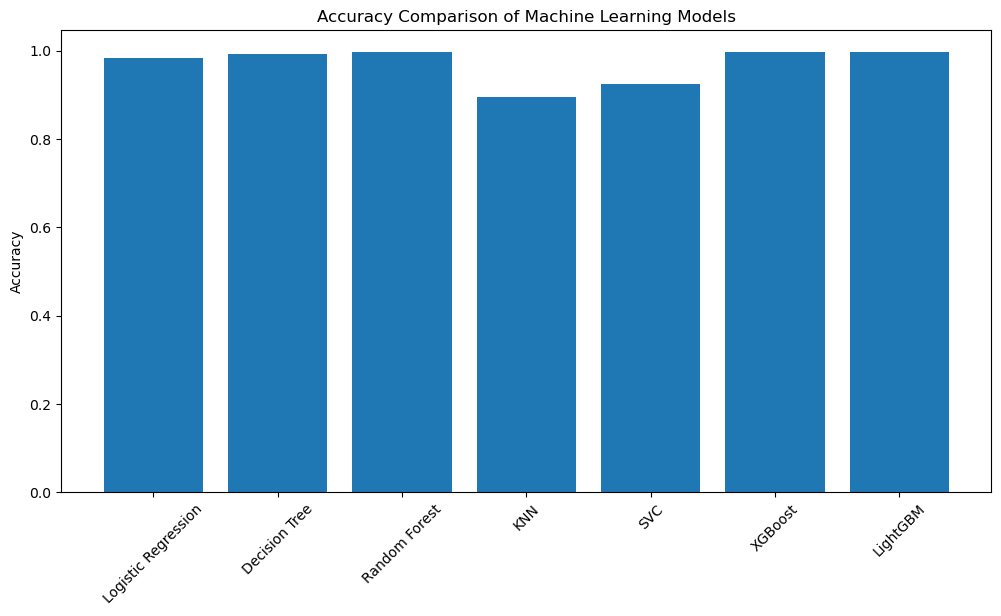

In [157]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVC",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_svc),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_lgb)
    ]
})

plt.figure(figsize=(12,6))

plt.bar(results["Model"], results["Accuracy"])

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Machine Learning Models")

plt.show()

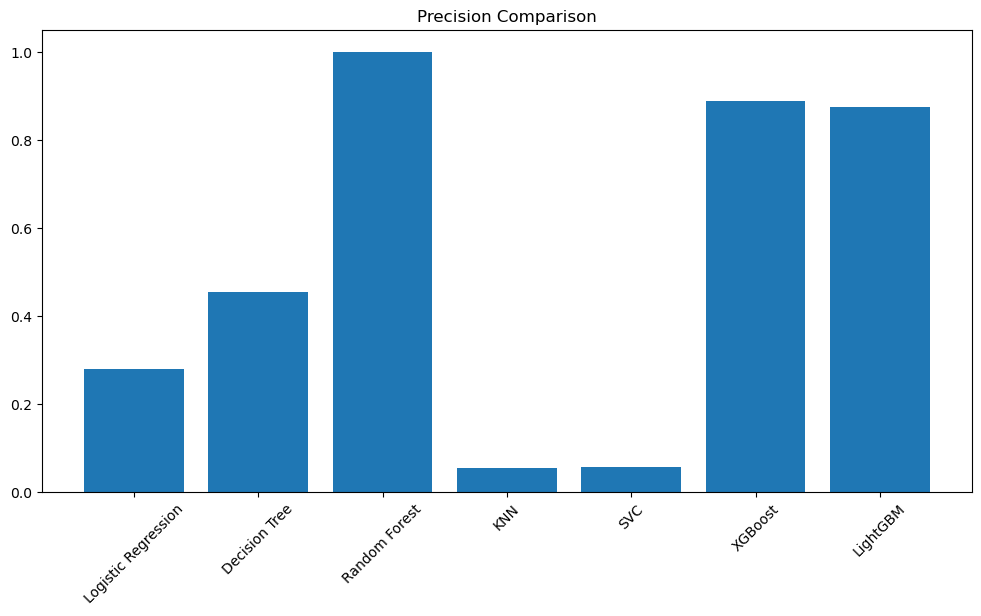

In [159]:
results["Precision"]=[
    precision_score(y_test,y_pred_lr),
    precision_score(y_test,y_pred_dt),
    precision_score(y_test,y_pred_rf),
    precision_score(y_test,y_pred_knn),
    precision_score(y_test,y_pred_svc),
    precision_score(y_test,y_pred_xgb),
    precision_score(y_test,y_pred_lgb)
]

plt.figure(figsize=(12,6))

plt.bar(results["Model"],results["Precision"])

plt.xticks(rotation=45)

plt.title("Precision Comparison")

plt.show()

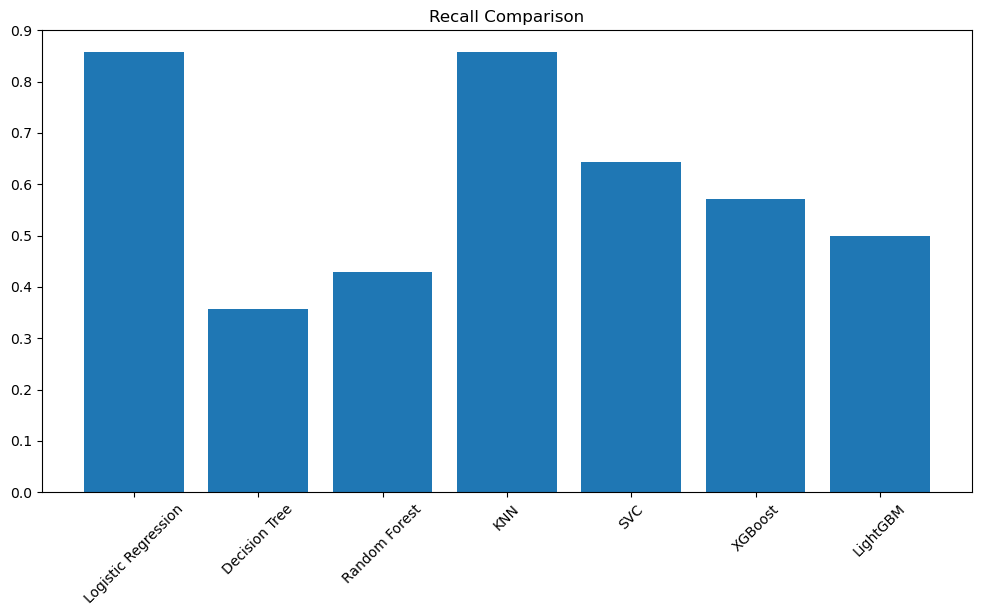

In [161]:
results["Recall"]=[
    recall_score(y_test,y_pred_lr),
    recall_score(y_test,y_pred_dt),
    recall_score(y_test,y_pred_rf),
    recall_score(y_test,y_pred_knn),
    recall_score(y_test,y_pred_svc),
    recall_score(y_test,y_pred_xgb),
    recall_score(y_test,y_pred_lgb)
]

plt.figure(figsize=(12,6))

plt.bar(results["Model"],results["Recall"])

plt.xticks(rotation=45)

plt.title("Recall Comparison")

plt.show()

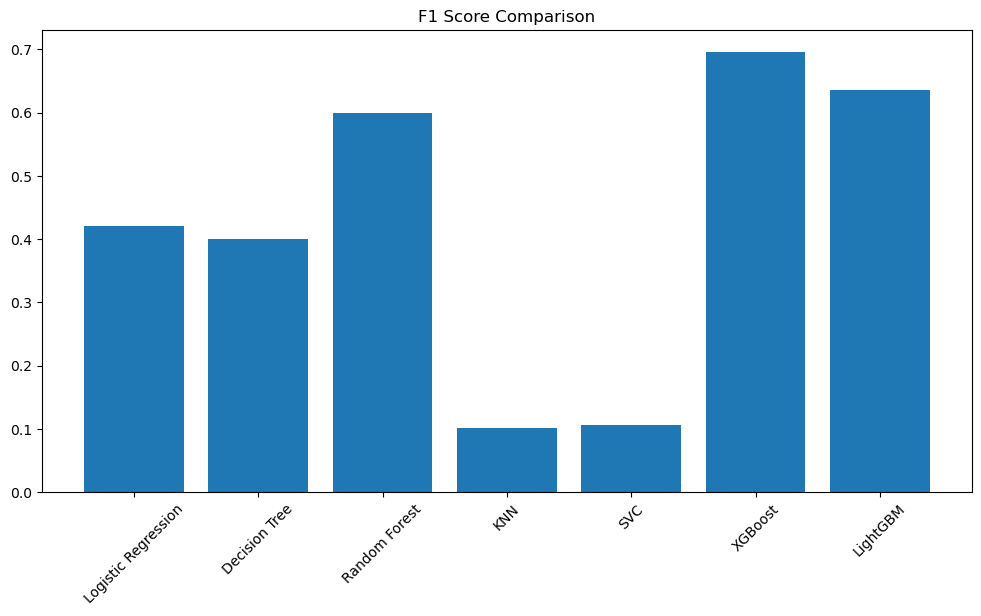

In [163]:
results["F1 Score"]=[
    f1_score(y_test,y_pred_lr),
    f1_score(y_test,y_pred_dt),
    f1_score(y_test,y_pred_rf),
    f1_score(y_test,y_pred_knn),
    f1_score(y_test,y_pred_svc),
    f1_score(y_test,y_pred_xgb),
    f1_score(y_test,y_pred_lgb)
]

plt.figure(figsize=(12,6))

plt.bar(results["Model"],results["F1 Score"])

plt.xticks(rotation=45)

plt.title("F1 Score Comparison")

plt.show()

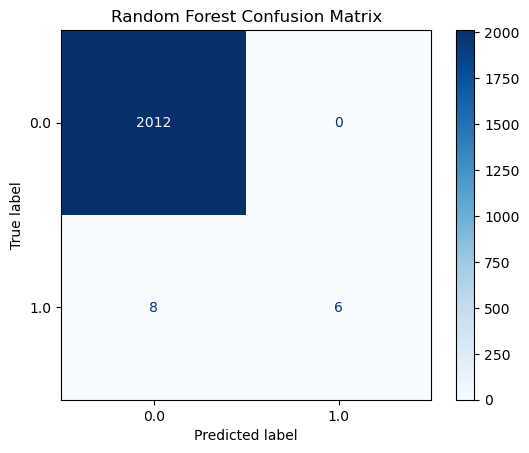

In [165]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [167]:
y_pred_lr
y_pred_dt
y_pred_knn
y_pred_svc
y_pred_xgb
y_pred_lgb

array([0., 0., 0., ..., 0., 0., 0.])

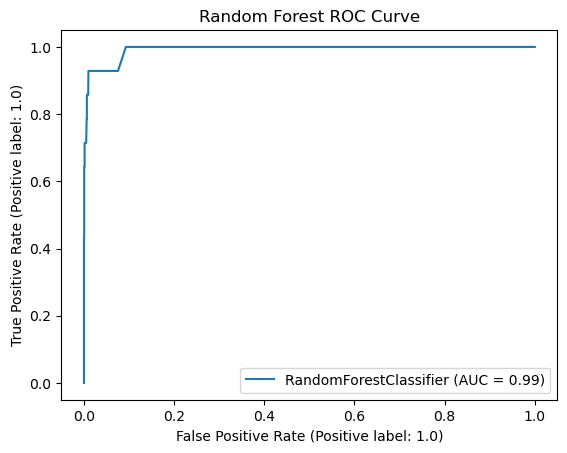

In [169]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

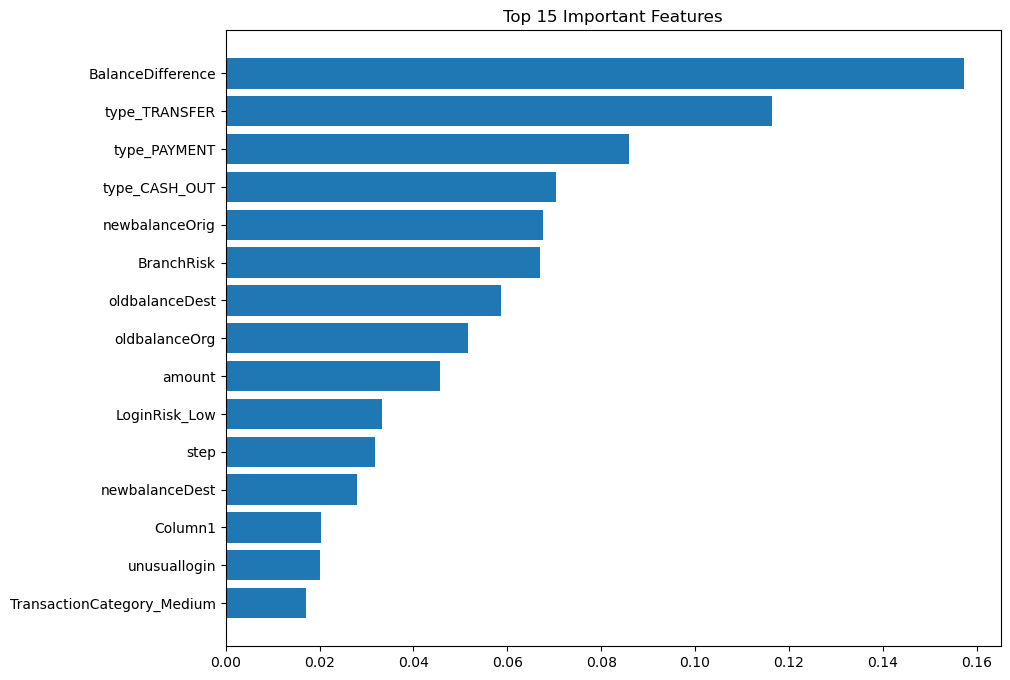

In [171]:
importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":rf.feature_importances_
})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [173]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.983712,0.279070,0.857143,0.421053
1,Decision Tree,0.992596,0.454545,0.357143,0.400000
2,Random Forest,0.996051,1.000000,0.428571,0.600000
3,KNN,0.895360,0.054054,0.857143,0.101695
4,SVC,0.925469,0.058065,0.642857,0.106509
5,XGBoost,0.996545,0.888889,0.571429,0.695652
6,LightGBM,0.996051,0.875000,0.500000,0.636364


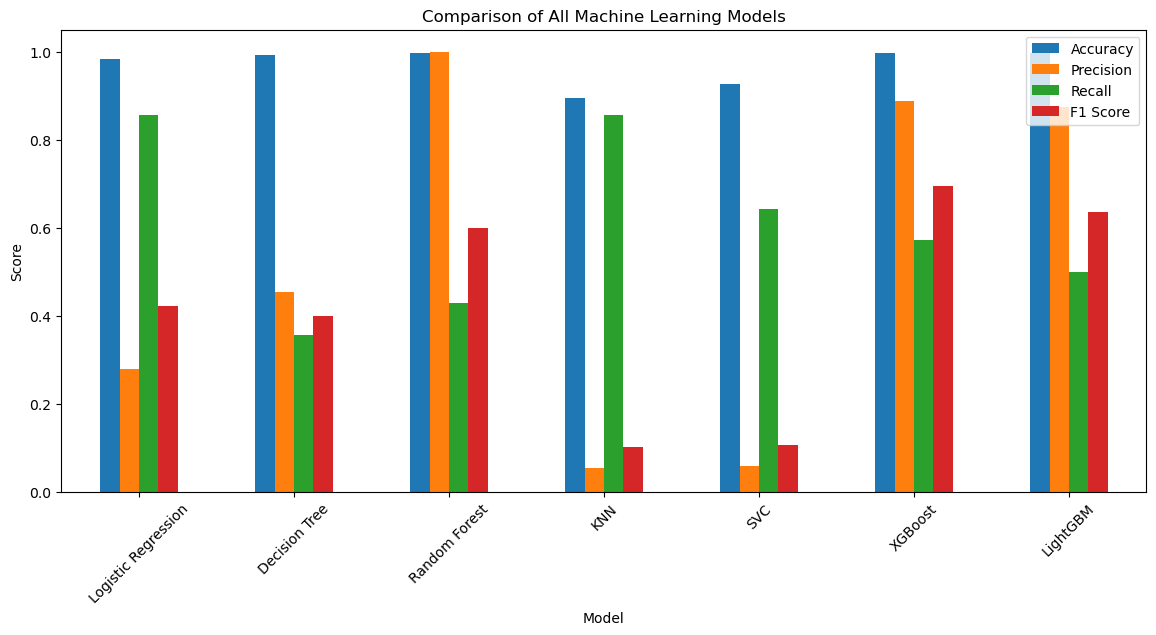

In [175]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(14,6)
)

plt.ylabel("Score")

plt.title("Comparison of All Machine Learning Models")

plt.xticks(rotation=45)

plt.show()

In [177]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [179]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "SVC": svc
}

In [181]:
models["XGBoost"] = xgb
models["LightGBM"] = lgb

In [183]:
comparison = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if hasattr(model, "predict_proba"):
        roc_auc = roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        )
    else:
        roc_auc = None

    comparison.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.983712,0.279070,0.857143,0.421053,0.932335
1,Decision Tree,0.992596,0.454545,0.357143,0.400000,0.677080
2,Random Forest,0.996051,1.000000,0.428571,0.600000,0.992225
3,KNN,0.895360,0.054054,0.857143,0.101695,0.917673
4,SVC,0.925469,0.058065,0.642857,0.106509,NaN
5,XGBoost,0.996545,0.888889,0.571429,0.695652,0.974723
6,LightGBM,0.996051,0.875000,0.500000,0.636364,0.974457


In [185]:
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,XGBoost,0.996545,0.888889,0.571429,0.695652,0.974723
2,Random Forest,0.996051,1.000000,0.428571,0.600000,0.992225
6,LightGBM,0.996051,0.875000,0.500000,0.636364,0.974457
1,Decision Tree,0.992596,0.454545,0.357143,0.400000,0.677080
0,Logistic Regression,0.983712,0.279070,0.857143,0.421053,0.932335
4,SVC,0.925469,0.058065,0.642857,0.106509,NaN
3,KNN,0.895360,0.054054,0.857143,0.101695,0.917673


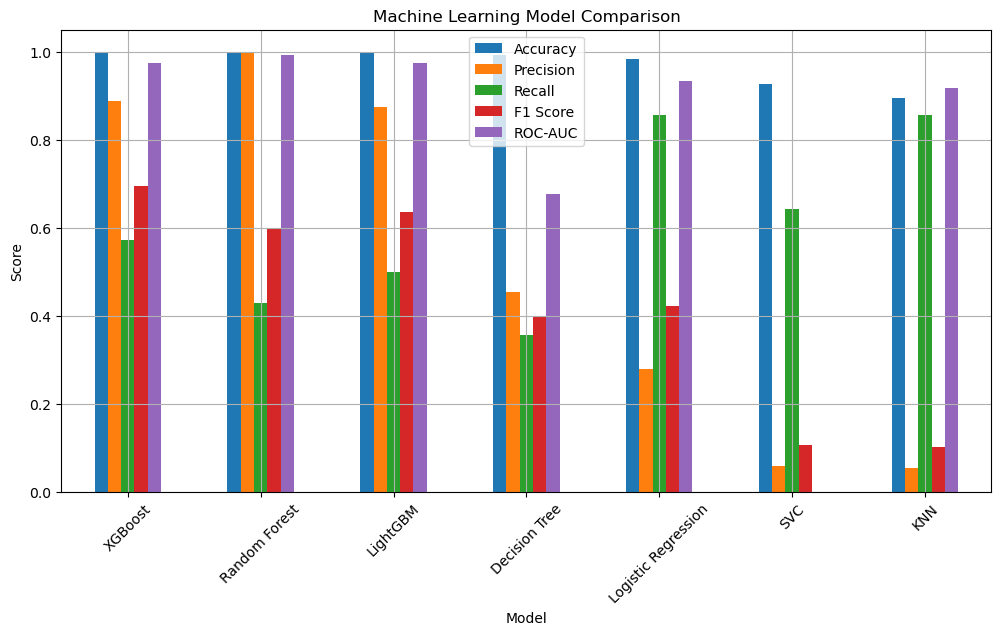

In [187]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [189]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : XGBoost


In [191]:
best_model = models[best_model_name]

In [193]:
print(best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


In [195]:
joblib.dump(
    best_model,
    "fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [197]:
loaded_model = joblib.load(
    "fraud_model.pkl"
)

print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


In [199]:
prediction = loaded_model.predict(X_test)

prediction[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [201]:
print("Accuracy :", accuracy_score(y_test, prediction))
print("Precision :", precision_score(y_test, prediction))
print("Recall :", recall_score(y_test, prediction))
print("F1 Score :", f1_score(y_test, prediction))

Accuracy : 0.9965449160908193
Precision : 0.8888888888888888
Recall : 0.5714285714285714
F1 Score : 0.6956521739130435


In [203]:
import sqlite3
import pandas as pd

In [205]:
df = pd.read_csv("Fraud_Detection_Feature_Engineered.csv")

In [207]:
conn = sqlite3.connect("fraud_detection.db")

cursor = conn.cursor()

print("Database Created Successfully")

Database Created Successfully


In [209]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (

TransactionID TEXT,
TransactionDate TEXT,
Amount REAL,
MerchantID TEXT,
TransactionType TEXT,
Location TEXT,
IsFraud INTEGER

)
""")

conn.commit()

print("Transactions Table Created Successfully")

Transactions Table Created Successfully


In [211]:
df.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Data Inserted Successfully")

Data Inserted Successfully


In [213]:
cursor.execute("SELECT COUNT(*) FROM transactions")

rows = cursor.fetchone()[0]

print("Total Records :", rows)

Total Records : 10127


In [215]:
query = "SELECT * FROM transactions LIMIT 10"

pd.read_sql(query, conn)

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,...,TransactionHour,TransactionMonth,TransactionDay,WeekendTransaction,HighAmountTransaction,BalanceDifference,FraudRiskLevel,BranchRisk,LoginRisk,TransactionCategory
0,7,PAYMENT,Espana,1526.50,C1908839976,0.0,0.0,M1304522697,0.0,0.0,...,14,1,3,0,0,0.0,Low,0.000000,High,Medium
1,7,PAYMENT,Honduras,1620.17,C70432899,0.0,0.0,M252297858,0.0,0.0,...,22,1,5,0,0,0.0,Low,0.000000,Low,Medium
2,7,PAYMENT,Indonesia,5689.82,C332151172,0.0,0.0,M1430674428,0.0,0.0,...,9,1,7,1,0,0.0,Low,0.006349,Low,Medium
3,7,PAYMENT,Estados Unidos,2211.07,C1148172078,0.0,0.0,M650835126,0.0,0.0,...,14,1,6,1,0,0.0,Low,0.007794,High,Medium
4,7,PAYMENT,Estados Unidos,824.63,C1142006014,0.0,0.0,M745868137,0.0,0.0,...,9,1,6,1,0,0.0,Low,0.007794,High,Small
5,7,PAYMENT,Italia,10330.01,C712723382,0.0,0.0,M1705236425,0.0,0.0,...,22,1,6,1,0,0.0,Low,0.006452,Low,Large
6,7,PAYMENT,Francia,10536.99,C1416013849,0.0,0.0,M818628762,0.0,0.0,...,22,1,8,0,0,0.0,Low,0.004082,High,Large
7,7,PAYMENT,Irlanda,12317.87,C1075676110,0.0,0.0,M997919131,0.0,0.0,...,14,1,9,0,0,0.0,Low,0.000000,Low,Large
8,7,PAYMENT,Finlandia,9633.05,C1522288781,0.0,0.0,M819545304,0.0,0.0,...,22,1,10,0,0,0.0,Low,0.000000,Low,Medium
9,7,PAYMENT,Espana,2515.77,C477541118,0.0,0.0,M2141341498,0.0,0.0,...,14,1,11,0,0,0.0,Low,0.000000,High,Medium


In [217]:
query = "PRAGMA table_info(transactions)"

pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,step,INTEGER,0,None,0
1,1,type,TEXT,0,None,0
2,2,branch,TEXT,0,None,0
3,3,amount,REAL,0,None,0
4,4,nameOrig,TEXT,0,None,0
5,5,oldbalanceOrg,REAL,0,None,0
6,6,newbalanceOrig,REAL,0,None,0
7,7,nameDest,TEXT,0,None,0
8,8,oldbalanceDest,REAL,0,None,0
9,9,newbalanceDest,REAL,0,None,0


In [219]:
query = """
SELECT *
FROM transactions
WHERE `isFraud - Copy` = 1
"""

pd.read_sql(query, conn)

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,...,TransactionHour,TransactionMonth,TransactionDay,WeekendTransaction,HighAmountTransaction,BalanceDifference,FraudRiskLevel,BranchRisk,LoginRisk,TransactionCategory
0,1,TRANSFER,India,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,...,9,1,7,1,0,181.00,Low,0.002558,Low,Small
1,1,TRANSFER,Turquia,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,...,22,1,25,0,0,2806.00,Low,0.010929,Low,Medium
2,1,TRANSFER,Brasil,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,...,9,1,11,0,0,20128.00,Low,0.006757,Low,Large
3,1,TRANSFER,Italia,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.00,0.00,...,14,1,6,1,1,1277212.77,High,0.006452,High,None
4,1,TRANSFER,Filipinas,35063.63,C1364127192,35063.63,0.0,C1136419747,0.00,0.00,...,22,1,12,0,0,35063.63,Low,0.017647,High,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,6,CASH_OUT,Canada,10565.00,C1191732945,10565.00,0.0,C418964192,36275.00,24380.72,...,9,1,13,1,0,10565.00,Low,0.018868,Low,Large
64,6,CASH_OUT,Estados Unidos,85354.69,C158801009,85354.69,0.0,C382431057,11170.00,10612.55,...,14,1,7,1,0,85354.69,Low,0.007794,Low,Very Large
65,6,CASH_OUT,Rusia,13704.00,C1421965867,13704.00,0.0,C1438594533,3382.84,143675.35,...,22,1,5,0,0,13704.00,Low,0.024691,Low,Large
66,7,CASH_OUT,Australia,262434.54,C383717053,262434.54,0.0,C380242442,19525.79,438233.86,...,9,1,6,1,1,262434.54,High,0.009479,High,Very Large


In [221]:
query = """
SELECT *
FROM transactions
WHERE IsFraud = 1
"""

pd.read_sql(query, conn)

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,...,TransactionHour,TransactionMonth,TransactionDay,WeekendTransaction,HighAmountTransaction,BalanceDifference,FraudRiskLevel,BranchRisk,LoginRisk,TransactionCategory


In [223]:
query = """
SELECT
`isFraud - Copy`,
COUNT(*) AS Total
FROM transactions
GROUP BY `isFraud - Copy`
"""

pd.read_sql(query, conn)

,isFraud - Copy,Total
0,0.0,10059
1,1.0,68


In [225]:
query = """
SELECT
amount,
branch,
type
FROM transactions
ORDER BY amount DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,amount,branch,type
0,10000000.00,Panama,CASH_OUT
1,10000000.00,Cuba,TRANSFER
2,3776389.09,China,TRANSFER
3,2943845.35,Haiti,TRANSFER
4,2940764.72,Italia,TRANSFER
5,2930418.44,Nicaragua,TRANSFER
6,2930418.44,Guatemala,CASH_OUT
7,2861134.92,Mexico,TRANSFER
8,2837270.65,India,TRANSFER
9,2604219.11,Indonesia,TRANSFER


In [227]:
conn.commit()

print("Changes Saved")

Changes Saved


In [229]:
conn.close()

print("Database Closed Successfully")

Database Closed Successfully


In [232]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [236]:
import networkx as nx
import matplotlib.pyplot as plt

In [238]:
G = nx.Graph()

In [240]:
for _, row in df.iterrows():

    customer = row["nameOrig"]
    transaction = row["type"]
    branch = row["branch"]
    destination = row["nameDest"]

    G.add_edge(customer, transaction)
    G.add_edge(transaction, branch)
    G.add_edge(branch, destination)

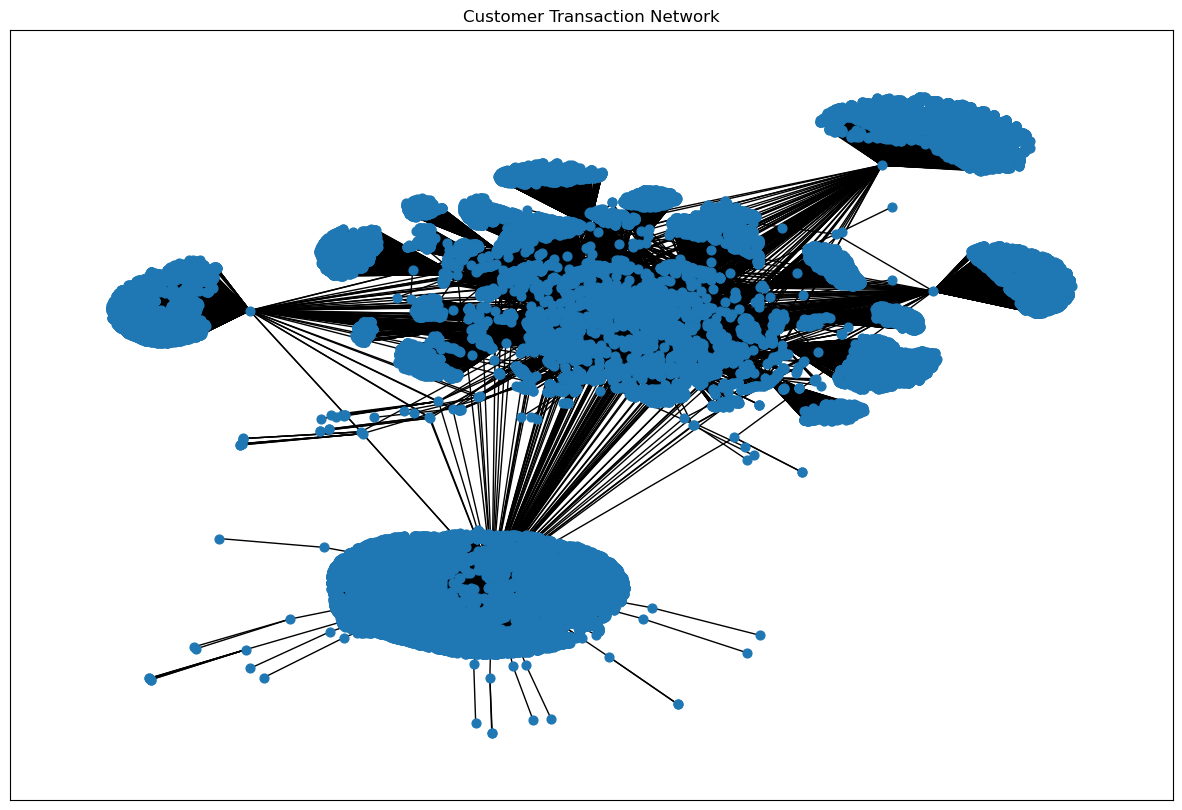

In [243]:
plt.figure(figsize=(15,10))

nx.draw_networkx(
    G,
    node_size=40,
    with_labels=False
)

plt.title("Customer Transaction Network")

plt.show()

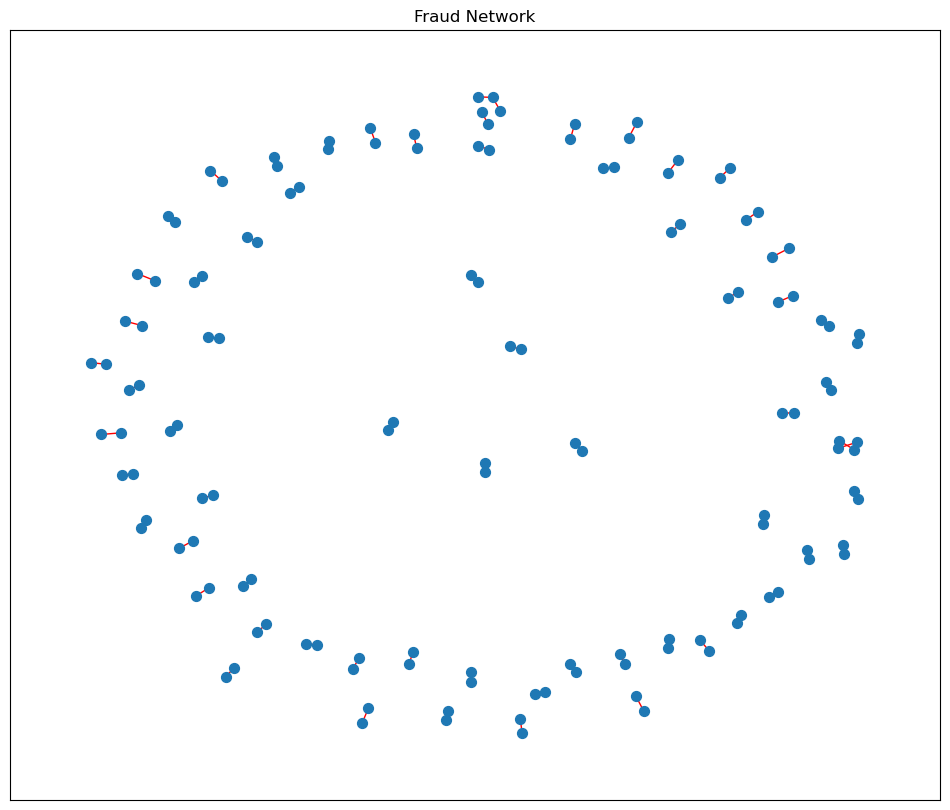

In [244]:
fraud_df = df[df["isFraud - Copy"] == 1]

FG = nx.Graph()

for _, row in fraud_df.iterrows():

    FG.add_edge(row["nameOrig"], row["nameDest"])

plt.figure(figsize=(12,10))

nx.draw_networkx(
    FG,
    node_size=50,
    edge_color="red",
    with_labels=False
)

plt.title("Fraud Network")

plt.show()

In [272]:
pip install secure-smtplib

In [274]:
import smtplib
from email.mime.text import MIMEText

In [276]:
def send_email():

    sender = "your_email@gmail.com"
    password = "your_app_password"

    receiver = "receiver@gmail.com"

    message = MIMEText("Fraud Transaction Detected!")

    message["Subject"] = "Fraud Alert"

    message["From"] = sender
    message["To"] = receiver

    server = smtplib.SMTP("smtp.gmail.com",587)

    server.starttls()

    server.login(sender,password)

    server.send_message(message)

    server.quit()

In [278]:
if prediction[0] == 1:

    send_email()

    print("Email Sent")

In [280]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [282]:
import streamlit as st
import joblib

model = joblib.load("fraud_model.pkl")

In [288]:
amount = st.number_input("Transaction Amount")

transaction_type = st.selectbox(
    "Transaction Type",
    ["PAYMENT","TRANSFER","CASH_OUT","DEBIT"]
)

branch = st.selectbox(
    "Branch",
    list(df["branch"].unique())
)

login = st.number_input("Unusual Login")

account = st.selectbox(
    "Account Type",
    list(df["Acct type"].unique())
)

2026-06-29 19:11:13.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:11:13.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [290]:
if st.button("Predict Fraud"):

    # Build input DataFrame using the same
    # preprocessing pipeline as training

    prediction = model.predict(input_data)

    if prediction[0] == 1:

        st.error("🚨 Fraud")

    else:

        st.success("✅ Safe Transaction")

2026-06-29 19:17:37.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:17:37.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:17:37.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:17:37.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:17:37.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 19:17:37.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [292]:
df.to_csv("cleaned_fraud_detection.csv", index=False)